In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [17]:
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

df_jfk = df[df['Airport Code'] == 'JFK'].copy()

df_jfk['Date'] = pd.to_datetime(
    df_jfk['Year'].astype(str) + '-' + df_jfk['Month'] + '-01'
)

ts = df_jfk.groupby('Date')['Total Passengers'].sum().sort_index()

ts.head(10)

Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
1977-06-01    1906396
1977-07-01    2373334
1977-08-01    2372987
1977-09-01    2010979
1977-10-01    1806198
Name: Total Passengers, dtype: int64

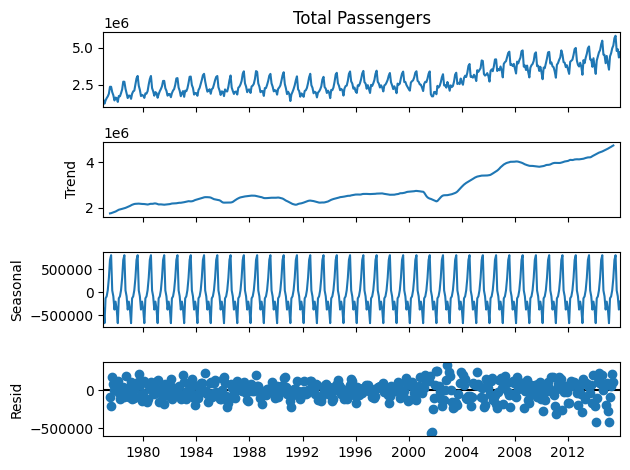

In [18]:
decomp_add = seasonal_decompose(ts, model='additive', period=12)

decomp_add.plot()
plt.show()

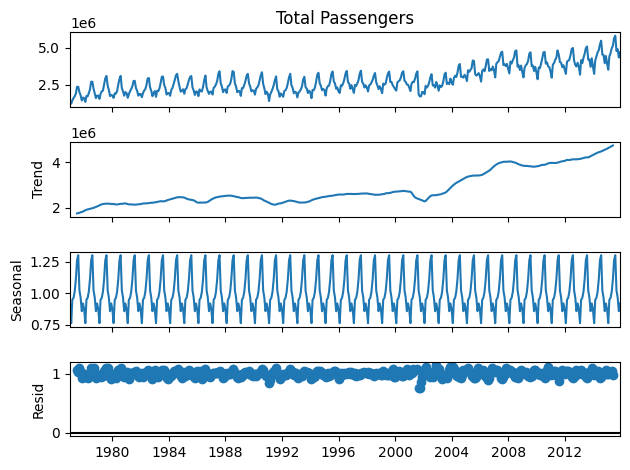

In [19]:
decomp_mul = seasonal_decompose(ts, model='multiplicative', period=12)

decomp_mul.plot()
plt.show()

In [20]:
## Train - Test Split 

train = ts[:-24]
test = ts[-24:]


## Time Series Decomposition

The time series was decomposed into its components:

- Trend: shows the long-term upward movement
- Seasonality: shows repeating yearly patterns
- Residual: represents irregular fluctuations

Both additive and multiplicative decomposition were applied.

The multiplicative decomposition better represents the data since the seasonal variation increases with the level of the series.

In [21]:
trend = decomp_mul.trend
seasonal = decomp_mul.seasonal

# the last trend values
last_trend = trend.dropna().iloc[-1]

# the last 12 seasonal pattern
trend_slope = trend.dropna().diff().mean()

seasonal_pattern = seasonal[-12:]

forecast = []

for i in range(len(test)):
    trend_value = last_trend + (i * trend_slope)
    value = last_trend * seasonal_pattern[i % 12]
    forecast.append(value)

decomp_forecast = pd.Series(forecast, index=test.index)

decomp_forecast

C:\Users\Merve\AppData\Local\Temp\ipykernel_2824\2098473249.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  value = last_trend * seasonal_pattern[i % 12]


Date
2014-01-01    4.118320e+06
2014-02-01    3.601925e+06
2014-03-01    4.478234e+06
2014-04-01    4.551864e+06
2014-05-01    4.779210e+06
2014-06-01    5.257738e+06
2014-07-01    5.964668e+06
2014-08-01    6.155428e+06
2014-09-01    4.828873e+06
2014-10-01    4.570146e+06
2014-11-01    4.051792e+06
2014-12-01    4.343971e+06
2015-01-01    4.118320e+06
2015-02-01    3.601925e+06
2015-03-01    4.478234e+06
2015-04-01    4.551864e+06
2015-05-01    4.779210e+06
2015-06-01    5.257738e+06
2015-07-01    5.964668e+06
2015-08-01    6.155428e+06
2015-09-01    4.828873e+06
2015-10-01    4.570146e+06
2015-11-01    4.051792e+06
2015-12-01    4.343971e+06
dtype: float64

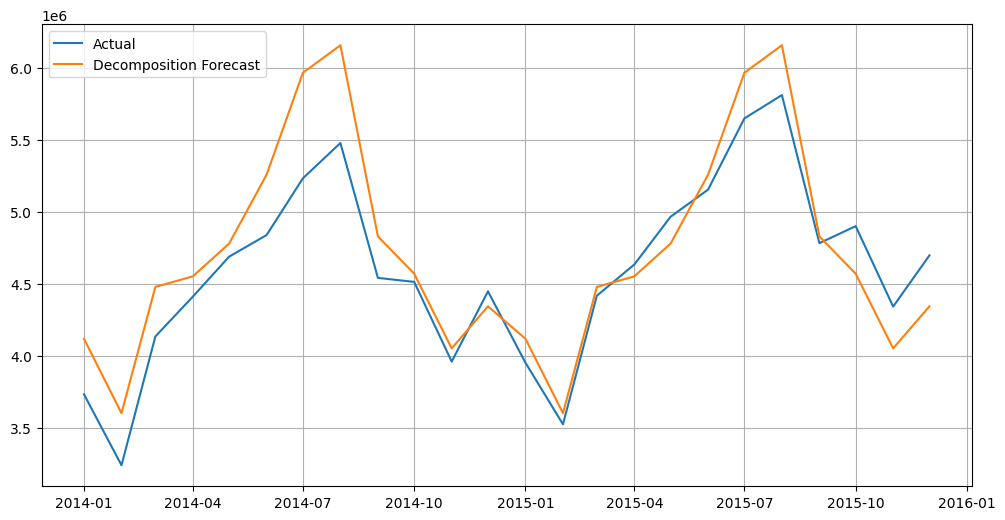

In [22]:
plt.figure(figsize=(12,6))

plt.plot(test, label='Actual')
plt.plot(decomp_forecast, label='Decomposition Forecast')

plt.legend()
plt.grid(True)
plt.show()

## Decomposition-Based Forecast Evaluation

The decomposition-based forecast successfully captures the seasonal pattern of the data.

However, it shows noticeable deviations from actual values:

- Overestimation at peak periods
- Inaccurate representation of trend dynamics
- Lack of adaptability compared to smoothing-based methods

Although decomposition is useful for understanding the structure of the time series, it is less effective for forecasting.

In comparison, the Holt-Winters multiplicative model provides more accurate and reliable forecasts.